In [1]:
!pip install xgboost seaborn numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------------------- ------- 7.6/9.3 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 36.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Sebastiao\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Importações

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
np.random.seed(42)


## 1. Carregar e explorar

Comecei do começo: ler o csv e dar uma olhada na cara dos dados (`head`, `shape`, `dtypes`). São 3000
incidentes e 10 colunas.

In [2]:
df = pd.read_csv('dataset.csv')

print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)
df.head()


Shape: (3000, 10)

Tipos:
Country                                    str
Year                                     int64
Attack Type                                str
Target Industry                            str
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                              str
Security Vulnerability Type                str
Defense Mechanism Used                     str
Incident Resolution Time (in Hours)      int64
dtype: object


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


Conferindo valores ausentes e as estatísticas das colunas numéricas. Não tem nenhum NaN no dataset
inteiro, o que já é meio estranho pra dados de incidente real.

In [3]:
print('NaN por coluna:')
print(df.isna().sum())

df.describe()


NaN por coluna:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


Olhando a descritiva, a perda financeira vai de 0,5 a ~100 com média quase exata de 50, e o tempo de
resolução fica espalhado de 1 a 72 horas. Tudo muito "redondo". Vou olhar as categóricas com `value_counts`.

In [4]:
for c in df.select_dtypes(exclude='number').columns:
    print(f'\n{c}:')
    print(df[c].value_counts())



Country:
Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

Attack Type:
Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

Target Industry:
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

Attack Source:
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

Security Vulnerability Type:
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

Defense Mechanism

As contagens são quase iguais dentro de cada coluna. Nenhum país, tipo de ataque ou indústria se
destaca. Em dados reais eu esperaria bem mais desequilíbrio (phishing muito mais comum que MITM, por exemplo).
Isso reforça a hipótese de dataset gerado artificialmente.

### Distribuições e outliers

Histograma pra ver a distribuição e boxplot pra procurar outliers, igual a gente fez na EDA.

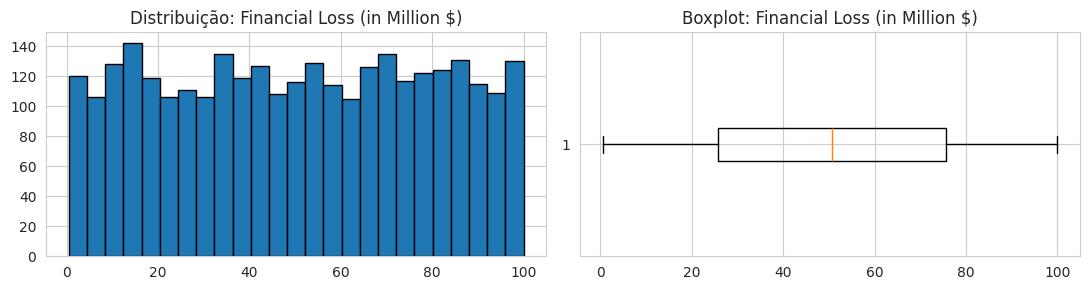

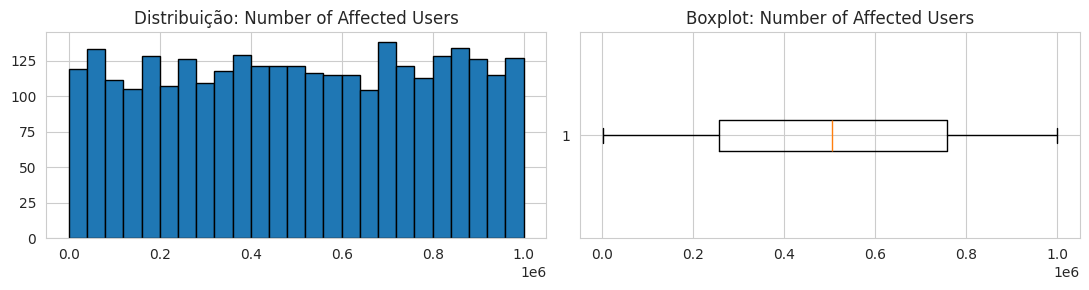

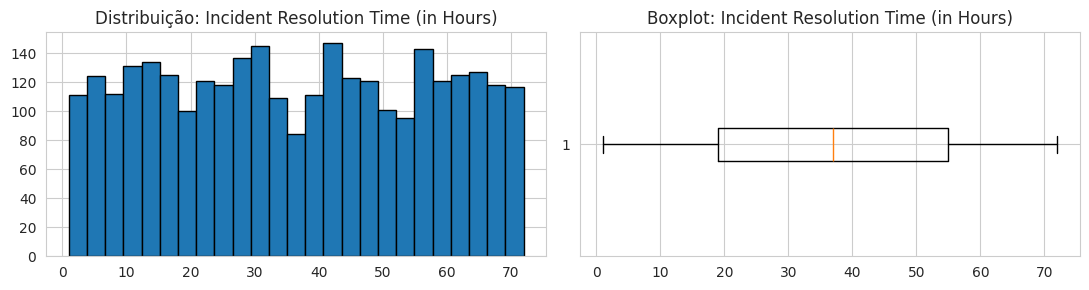

In [5]:
num_cols = ['Financial Loss (in Million $)', 'Number of Affected Users',
            'Incident Resolution Time (in Hours)']

for col in num_cols:
    plt.figure(figsize=(11, 3))
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=25, edgecolor='k')
    plt.title(f'Distribuição: {col}')
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()


Os boxplots praticamente não têm pontos fora dos bigodes, então não tem outlier pra tratar. As
distribuições parecem quase uniformes (achatadas), sem aquela cauda longa que perda financeira costuma ter na
vida real.

### Correlações

Aqui é o ponto que mais me chamou atenção na EDA. Olhando a correlação entre as numéricas: 

                                      Year  Financial Loss (in Million $)  \
Year                                 1.000                          0.011   
Financial Loss (in Million $)        0.011                          1.000   
Number of Affected Users             0.002                          0.002   
Incident Resolution Time (in Hours) -0.005                         -0.013   

                                     Number of Affected Users  \
Year                                                    0.002   
Financial Loss (in Million $)                           0.002   
Number of Affected Users                                1.000   
Incident Resolution Time (in Hours)                     0.006   

                                     Incident Resolution Time (in Hours)  
Year                                                              -0.005  
Financial Loss (in Million $)                                     -0.013  
Number of Affected Users                                       

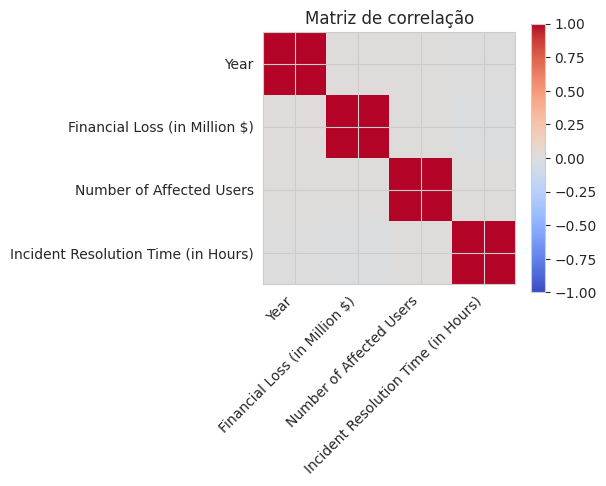

In [6]:
corr = df[['Year'] + num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(6, 5))
plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()


Todas as correlações fora da diagonal são basicamente zero (a maior nem chega em 0,02). Ou seja, as
variáveis numéricas não têm relação nenhuma entre si. Isso já dá um sinal forte de que vai ser difícil prever
qualquer coisa a partir das outras colunas, mas vamos em frente.

## 2. Definir o alvo e criar uma feature

O alvo vem da coluna `Attack Source`. Vou transformar num problema binário: 1 se foi `Nation-state`, 0 pra
qualquer outra origem (Insider, Hacker Group, Unknown). Escolhi esse porque é uma pergunta que faz sentido num
contexto de segurança ("dá pra suspeitar que foi ataque estatal pelas características do incidente?").

Aproveitei também pra **criar uma feature nova**: perda financeira por usuário afetado.

Proporção da classe 1 (nation-state): 0.265
Ou seja, ~26% positivos -> classes um pouco desbalanceadas.


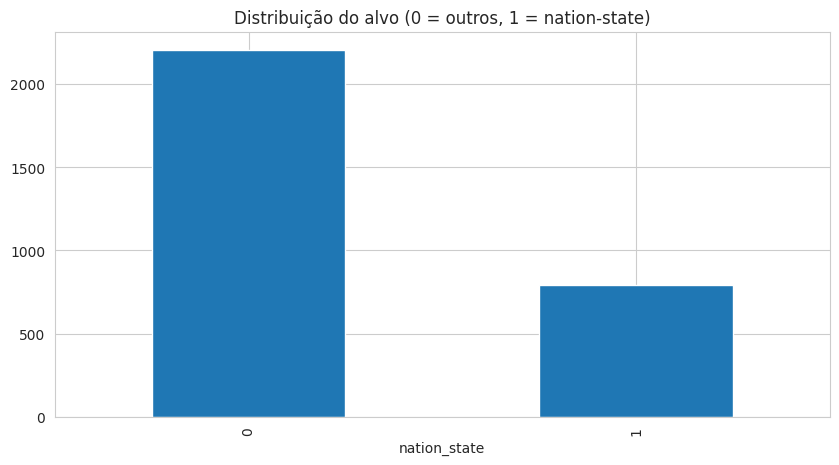

In [7]:
# feature nova: perda em dolar por usuario afetado
df['Loss_per_User'] = df['Financial Loss (in Million $)'] * 1e6 / df['Number of Affected Users']

# alvo binario
df['nation_state'] = (df['Attack Source'] == 'Nation-state').astype(int)

print('Proporção da classe 1 (nation-state):', round(df['nation_state'].mean(), 3))
print('Ou seja, ~26% positivos -> classes um pouco desbalanceadas.')

df['nation_state'].value_counts().plot(kind='bar')
plt.title('Distribuição do alvo (0 = outros, 1 = nation-state)')
plt.show()


## 3. Seleção de features (SelectKBest)

Antes de modelar, usei o `SelectKBest` com ANOVA (`f_classif`) só pra ver se alguma feature se destaca na hora
de separar as classes, como a gente fez no Iris. Quanto maior o score, melhor a feature separa.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features_numericas = ['Year', 'Financial Loss (in Million $)', 'Number of Affected Users',
                      'Incident Resolution Time (in Hours)', 'Loss_per_User']
features_categoricas = ['Country', 'Attack Type', 'Target Industry',
                        'Security Vulnerability Type', 'Defense Mechanism Used']

X = df.drop(columns=['Attack Source', 'nation_state'])
y = df['nation_state']

# preparo rapido so pra rodar o SelectKBest (numericas escalonadas + categoricas em one-hot)
oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_num = StandardScaler().fit_transform(X[features_numericas])
X_cat = oh.fit_transform(X[features_categoricas])
X_full = np.hstack([X_num, X_cat])
nomes = features_numericas + list(oh.get_feature_names_out(features_categoricas))

skb = SelectKBest(f_classif, k=8).fit(X_full, y)
scores = pd.Series(skb.scores_, index=nomes).sort_values(ascending=False)
print('Top 8 scores (ANOVA f_classif):')
print(scores.head(8).round(3))


Top 8 scores (ANOVA f_classif):
Defense Mechanism Used_Antivirus    4.918
Country_Japan                       4.380
Target Industry_IT                  3.487
Target Industry_Education           2.836
Target Industry_Retail              2.407
Target Industry_Healthcare          2.199
Country_India                       1.684
Attack Type_Man-in-the-Middle       1.197
dtype: float64


Os scores são todos baixinhos (o maior não passa de ~5). Como referência, no Iris a gente via scores na
casa das centenas pras pétalas. Aqui nenhuma feature separa bem as classes, o que de novo aponta pra ausência
de sinal. Mesmo assim não vou descartar nada e sigo com todas as colunas.

## 4. Pré-processamento com ColumnTransformer

Montei o pré-processamento igual ao do Titanic da aula: imputer + scaler nas numéricas, e imputer + one-hot nas
categóricas, tudo dentro de um `ColumnTransformer`. Mesmo sem NaN aqui, deixei os imputers pra deixar o pipeline
reutilizável.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

transformador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', transformador_numerico, features_numericas),
    ('cat', transformador_categorico, features_categoricas)
])
print('Pré-processador pronto.')


Pré-processador pronto.


## 5. Dividir em treino e teste

Como é classificação com classes desbalanceadas, usei `stratify=y` pra manter os ~26% de positivos nos dois
conjuntos. Separei 30% pro teste.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print('Treino:', X_train.shape[0], '| Teste:', X_test.shape[0])
print('Proporção positiva no treino:', round(y_train.mean(), 3),
      '| no teste:', round(y_test.mean(), 3))


Treino: 2100 | Teste: 900
Proporção positiva no treino: 0.265 | no teste: 0.264


## 6. Três modelos com pipeline

Montei um pipeline por modelo (todos com o mesmo pré-processador na frente): Regressão Logística, Random Forest
e XGBoost, que são os três sugeridos no enunciado. Comparei eles com `cross_val_score` (acurácia, 5 folds
estratificados) no treino.

Coloquei também o baseline como referência: se eu chutar sempre a classe maioria (não nation-state), acerto
~73,5%, que é a proporção dela. Qualquer modelo útil tem que passar disso.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                 random_state=42, eval_metric='logloss'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', modelo)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    print('{:22s} acc média: {:.3f} (+/- {:.3f})'.format(nome, scores.mean(), scores.std()*2))

print('\nBaseline (chutar sempre a classe maioria): {:.3f}'.format(1 - y_train.mean()))


Regressão Logística    acc média: 0.736 (+/- 0.000)


Random Forest          acc média: 0.733 (+/- 0.013)


XGBoost                acc média: 0.729 (+/- 0.015)

Baseline (chutar sempre a classe maioria): 0.735


Os três ficaram colados no baseline (~0,73). Nem o XGBoost, nem o Random Forest, nem a Regressão
Logística conseguiram extrair alguma coisa. Já dá pra desconfiar que o problema não é o modelo, e sim os dados,
mas vou tentar otimizar mesmo assim.

## 7. Otimizar hiperparâmetros (GridSearchCV)

Peguei o pipeline do Random Forest e rodei um `GridSearchCV`, testando algumas combinações de `n_estimators`,
`max_depth` e até a estratégia de imputação (igual ao exemplo de integração pipeline + grid do Titanic).

In [12]:
from sklearn.model_selection import GridSearchCV

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 7, None],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
}

grid = GridSearchCV(pipe_rf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Melhores parâmetros:', grid.best_params_)
print('Melhor acurácia (CV):', round(grid.best_score_, 3))

melhor_modelo = grid.best_estimator_


Melhores parâmetros: {'classifier__max_depth': 3, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'mean'}
Melhor acurácia (CV): 0.735


Detalhe interessante: o grid escolheu a árvore **mais rasa** que ofereci (`max_depth=3`) e o menor
número de árvores. Faz sentido. Como não tem padrão pra aprender, deixar o modelo mais complexo só fazia ele
decorar o treino, então a melhor opção foi a mais simples. E mesmo assim a acurácia ficou em cima do baseline.

## 8. Avaliar no teste

Agora avalio o melhor modelo no conjunto de teste, que ficou separado o tempo todo. Como as classes são
desbalanceadas, não dá pra olhar só a acurácia, então puxei o `classification_report` (precisão, recall, f1),
a matriz de confusão e a curva ROC.

In [13]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)[:, 1]

print('Acurácia no teste:', round(accuracy_score(y_test, y_pred), 3))
print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred, target_names=['outros', 'nation-state']))


Acurácia no teste: 0.736

Relatório de classificação:
              precision    recall  f1-score   support

      outros       0.74      1.00      0.85       662
nation-state       0.00      0.00      0.00       238

    accuracy                           0.74       900
   macro avg       0.37      0.50      0.42       900
weighted avg       0.54      0.74      0.62       900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


O relatório entrega o jogo: o recall da classe "nation-state" é **0,00**. O modelo simplesmente classifica
tudo como "outros" pra garantir a acurácia alta. Ou seja, aquela acurácia de ~73% é só o baseline disfarçado, o
modelo não está identificando nenhum ataque estatal de verdade. É exatamente o tipo de armadilha que a gente
viu em aula: acurácia engana quando as classes estão desbalanceadas.

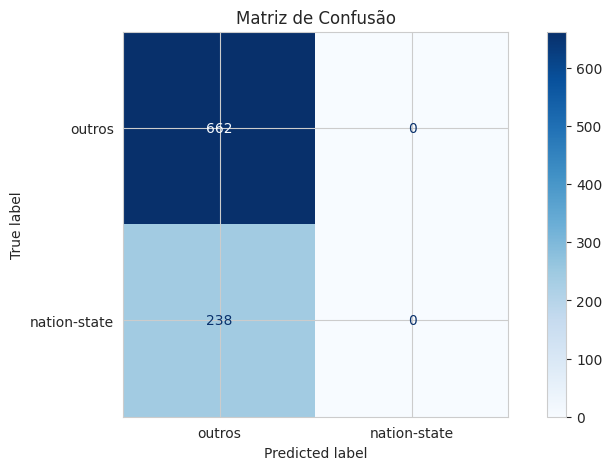

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['outros', 'nation-state'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()


A matriz confirma: a coluna do "nation-state" fica praticamente zerada, o modelo quase não arrisca prever
a classe positiva.

### Curva ROC

Fiz a curva ROC na mão com `roc_curve` e o AUC com `roc_auc_score`, como na aula.

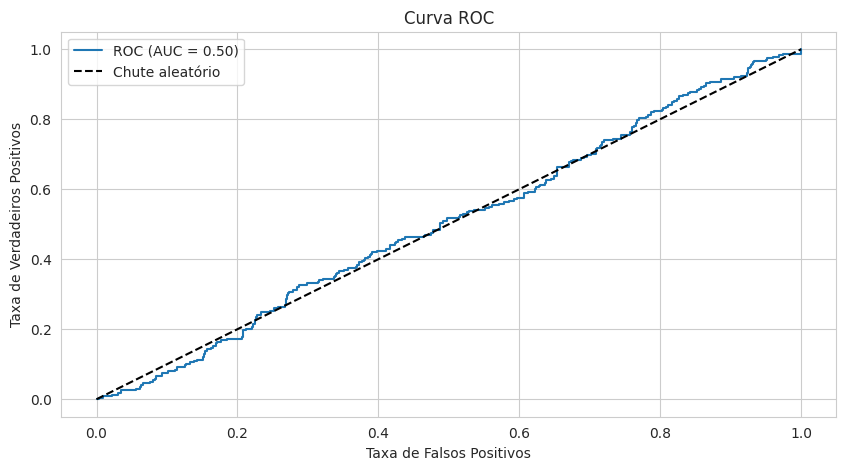

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chute aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()


A curva cola em cima da diagonal e o AUC fica em ~0,50, que é o valor de um modelo que chuta. Um
classificador bom teria a curva subindo pro canto superior esquerdo e AUC perto de 1. Aqui não acontece.

## 9. Interpretar: importância das features

Usei a `feature_importances_` do Random Forest pra ver quais colunas o modelo mais usou, igual a gente fez no
Iris.

Top 10 importâncias:
Financial Loss (in Million $)          0.1676
Loss_per_User                          0.1489
Number of Affected Users               0.1371
Incident Resolution Time (in Hours)    0.0865
Defense Mechanism Used_Antivirus       0.0500
Year                                   0.0386
Target Industry_Healthcare             0.0352
Country_Japan                          0.0342
Country_India                          0.0261
Target Industry_Education              0.0219
dtype: float64


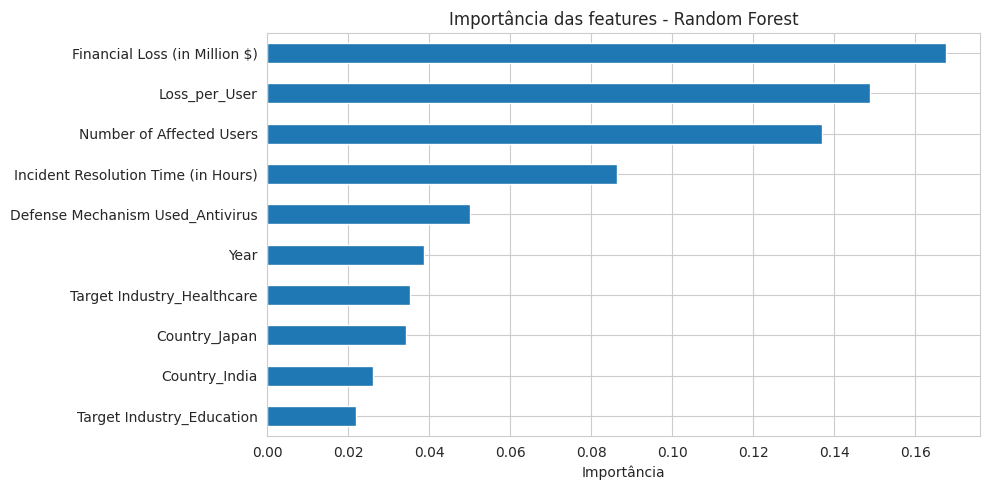

In [16]:
rf_final = melhor_modelo.named_steps['classifier']
oh_names = (melhor_modelo.named_steps['preprocessor']
            .named_transformers_['cat'].named_steps['onehot']
            .get_feature_names_out(features_categoricas))
todos_nomes = features_numericas + list(oh_names)

importancias = pd.Series(rf_final.feature_importances_, index=todos_nomes).sort_values(ascending=False)
print('Top 10 importâncias:')
print(importancias.head(10).round(4))

importancias.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Importância das features - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


As features que aparecem no topo são todas as numéricas contínuas (perda financeira, perda por usuário,
usuários afetados). Mas cuidado: isso não quer dizer que elas sejam úteis. A árvore tende a dar importância pra
variáveis contínuas só porque elas têm muitos valores diferentes e dão mais pontos de corte pra ela tentar. Como
a gente já viu que o AUC é 0,50, essa "importância" não está apontando pra um padrão real, é o modelo se agarrando
no ruído.

## 10. Overfitting / underfitting (curva de aprendizado)

Pra fechar, comparei a acurácia no treino com a do teste e plotei a curva de aprendizado, que foi a ferramenta
que a gente viu pra diagnosticar overfitting/underfitting.

In [17]:
rf_simples = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
]).fit(X_train, y_train)

print('RF (sem podar) acurácia no treino:', round(accuracy_score(y_train, rf_simples.predict(X_train)), 3))
print('RF (sem podar) acurácia no teste :', round(accuracy_score(y_test, rf_simples.predict(X_test)), 3))


RF (sem podar) acurácia no treino: 1.0
RF (sem podar) acurácia no teste : 0.727


Olha o tamanho do buraco: **100% no treino e ~73% no teste** (que é o baseline). Esse é o retrato clássico
de overfitting. Como os rótulos não têm relação com as features, a única forma de a árvore acertar tudo no treino
é decorar exemplo por exemplo, e decoreba não generaliza. Por isso o teste despenca pro nível do chute.

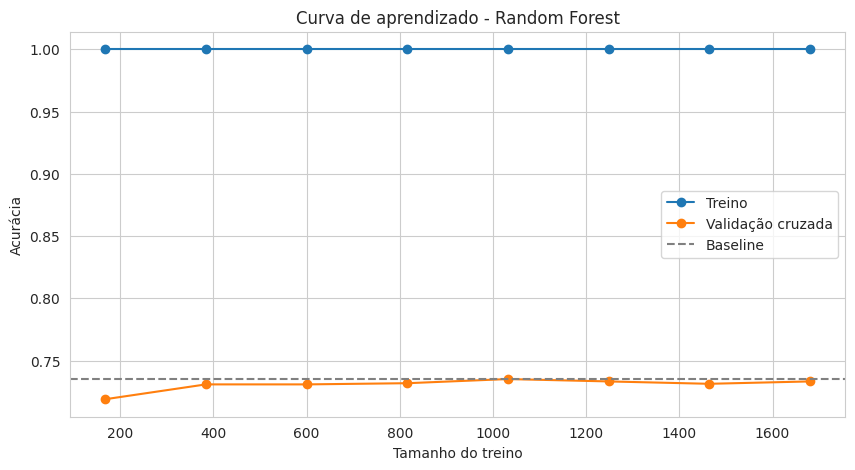

In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_simples, X_train, y_train, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, 'o-', label='Treino')
plt.plot(train_sizes, test_mean, 'o-', label='Validação cruzada')
plt.axhline(1 - y_train.mean(), color='gray', ls='--', label='Baseline')
plt.xlabel('Tamanho do treino')
plt.ylabel('Acurácia')
plt.title('Curva de aprendizado - Random Forest')
plt.legend()
plt.show()


A curva de aprendizado conta a mesma história: a linha do treino fica lá em cima perto de 1, a da
validação fica embaixo presa no baseline, e as duas não se aproximam por mais que eu dê mais dados. Quando isso
acontece (treino muito acima da validação, sem convergir) é overfitting, e nesse caso é overfitting em cima de
ruído.

## 11. Discussão e conclusão

**Resumo do que rolou.** Rodei o pipeline completo (EDA, pré-processamento com ColumnTransformer, seleção de
features, três modelos, otimização com GridSearch, avaliação no teste e interpretação) e em todas as etapas o
resultado foi o mesmo: nenhum modelo passa do baseline e o AUC fica em 0,50.

**Por que isso aconteceu (não é bug do pipeline).** As evidências foram se acumulando ao longo do notebook:

1. As correlações entre as numéricas são todas ~0.
2. As categóricas são quase uniformes, sem o desequilíbrio que dados reais teriam.
3. Os scores do SelectKBest são baixíssimos (nenhuma feature separa as classes).
4. Os três modelos empatam no baseline.
5. O GridSearch preferiu o modelo mais simples (otimizar não ajudou).
6. A curva de aprendizado mostra overfitting puro: treino em 1,0, validação no baseline.

Juntando tudo, a conclusão é que esse dataset é **sintético**: as colunas foram geradas de forma independente,
então não existe relação features → alvo pra um modelo aprender. Foi a mesma desconfiança que eu já tinha
anotado na EDA.

**Overfitting x underfitting x trade-off.** O Random Forest sem podar mostrou o lado do overfitting (alta
variância, decora o treino). A Regressão Logística, que é um modelo mais simples, também ficou no baseline, o que
mostra que não é questão de modelo fraco (underfitting) nem de modelo forte demais. Quando modelos de
complexidades bem diferentes dão o mesmo resultado ruim, o limite está nos dados, não no algoritmo.

**O que dava pra melhorar.** O passo de maior impacto seria trocar a fonte de dados por uma base real e rotulada
(tipo o NSL-KDD, que eu já usei em outro projeto, ou Heart Disease / Wine do próprio enunciado), onde existe
relação de verdade entre as variáveis e o alvo. Outras coisas que vimos em aula e que fariam sentido num dataset
com sinal: usar SMOTE pra tratar o desbalanceamento, testar outros modelos (KNN, SVM) e ajustar o limiar de
decisão olhando a curva precisão-recall. Mas, sendo honesto, em cima desse dataset nenhuma dessas técnicas ia
criar um padrão que não existe.

**Conclusão.** O pipeline está correto e sem vazamento (transformações ajustadas só no treino, teste isolado,
estratificação, métricas adequadas pra base desbalanceada). O resultado é negativo, mas é um resultado honesto:
saber reconhecer que não dá pra aprender nada de um dataset, em vez de reportar uma acurácia de 73% como se fosse
um bom modelo, é parte importante de fazer ML direito.
